## Моделирование VaR одного актива
1. Работа с временными рядами
2. Риск-метрики
   - VaR
   - Expected Shortfall
3. Различные подходы
   - Исторический
   - Параметрический
   - Теория экстремальных значений
   - Модели GARCH
   - Фильтрация временных рядов
4. Бектестирование
   - Биномиальный тест
    


In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("bmh")
plt.rcParams['font.family'] = 'DejaVu Sans'


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Данные 

### Загрузка и визуализация временных рядов

In [2]:
prices = pd.read_csv('dataset.csv')
prices['datetime'] = pd.to_datetime(prices['datetime'])
prices = prices.set_index('datetime')

prices.head()

,GAZP,SBER,LKOH,ROSN
datetime,,,,
2016-03-11,144.30,109.26,2669.0,301.60
2016-03-14,143.20,109.26,2658.5,301.05
2016-03-15,142.54,106.46,2647.5,300.60
2016-03-16,144.75,107.00,2703.0,301.25
2016-03-17,147.27,109.47,2750.0,309.40


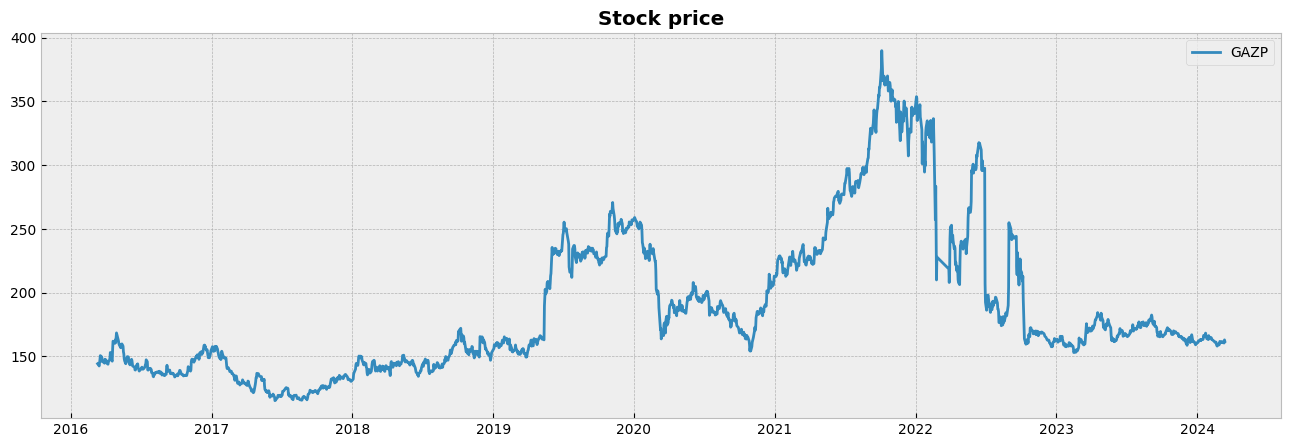

In [3]:
plot_fields =  ['GAZP']

fig = plt.figure(figsize=(16, 5))

plt.plot(prices[plot_fields])
plt.legend(plot_fields)

plt.title("Stock price", weight="bold")

plt.show()

### Предобработка

In [4]:
price = prices['GAZP']

price.head()

datetime
2016-03-11    144.30
2016-03-14    143.20
2016-03-15    142.54
2016-03-16    144.75
2016-03-17    147.27
Name: GAZP, dtype: float64

In [5]:
dX = price.diff() 

ret_log = np.log(price).diff()

ret = price.pct_change() 

ret

datetime
2016-03-11         NaN
2016-03-14   -0.007623
2016-03-15   -0.004609
2016-03-16    0.015504
2016-03-17    0.017409
                ...   
2024-03-06    0.004162
2024-03-07   -0.004578
2024-03-11   -0.002175
2024-03-12    0.015135
2024-03-13   -0.007485
Name: GAZP, Length: 2000, dtype: float64

In [6]:
ret = ret.dropna()

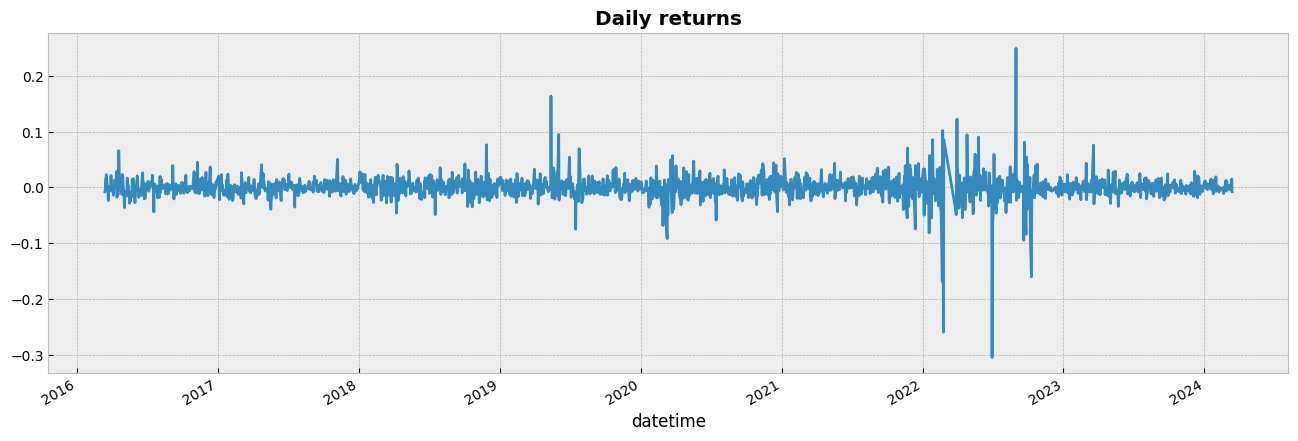

In [7]:
fig = plt.figure(figsize=(16, 5))

ret.plot()
plt.title("Daily returns", weight="bold")

plt.show()

### Построение гистограмм и графика Квантиль-Квантиль (Q-Q plot)

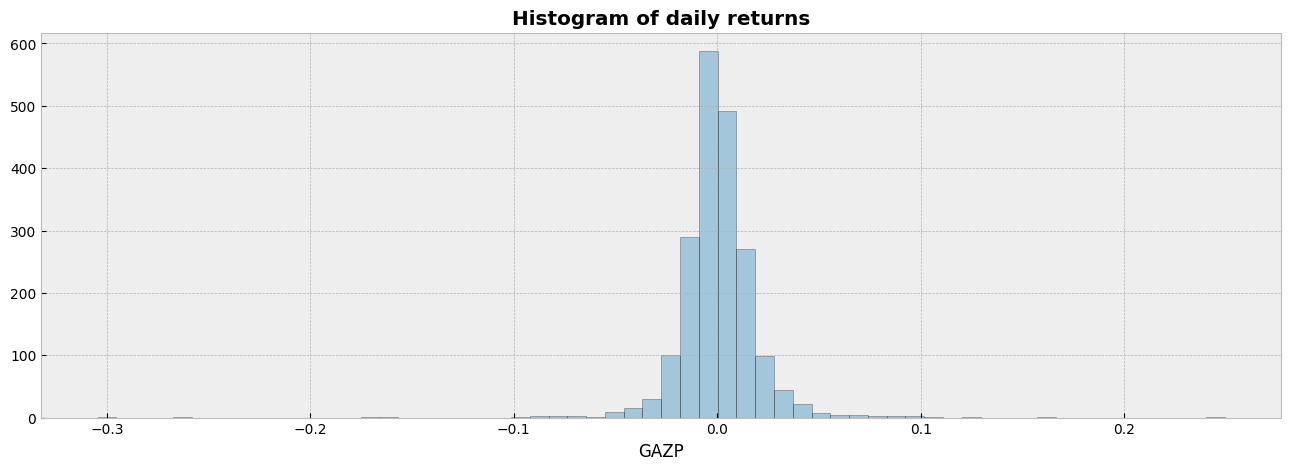

In [8]:
fig = plt.figure(figsize=(16, 5))

sns.distplot(ret, hist=True, kde=False, 
             bins=60,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

plt.title("Histogram of daily returns", weight="bold")

plt.show()

Проверим является ли распределение доходности нормальным

In [9]:
import scipy.stats as ss
params_norm = ss.norm.fit(ret)
print(params_norm)

(np.float64(0.00028777767821151355), np.float64(0.02110659725530061))


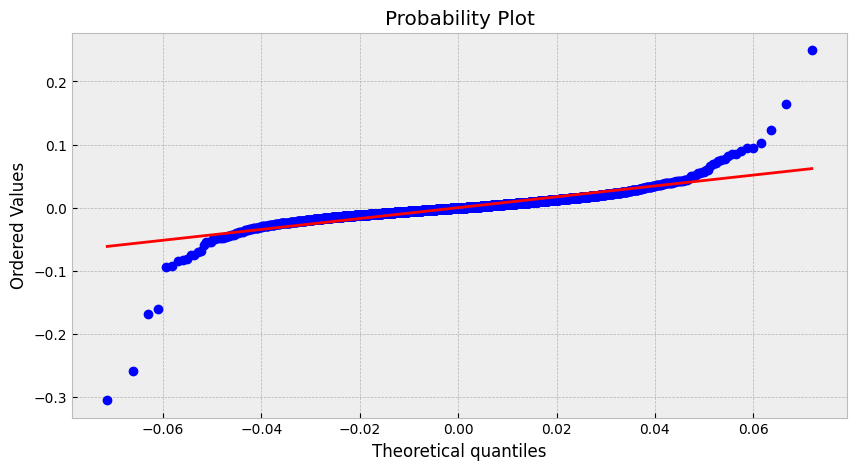

In [10]:
fig = plt.figure(figsize=(10, 5))
ss.probplot(ret, dist=ss.norm(*params_norm), plot=plt)
plt.show()


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


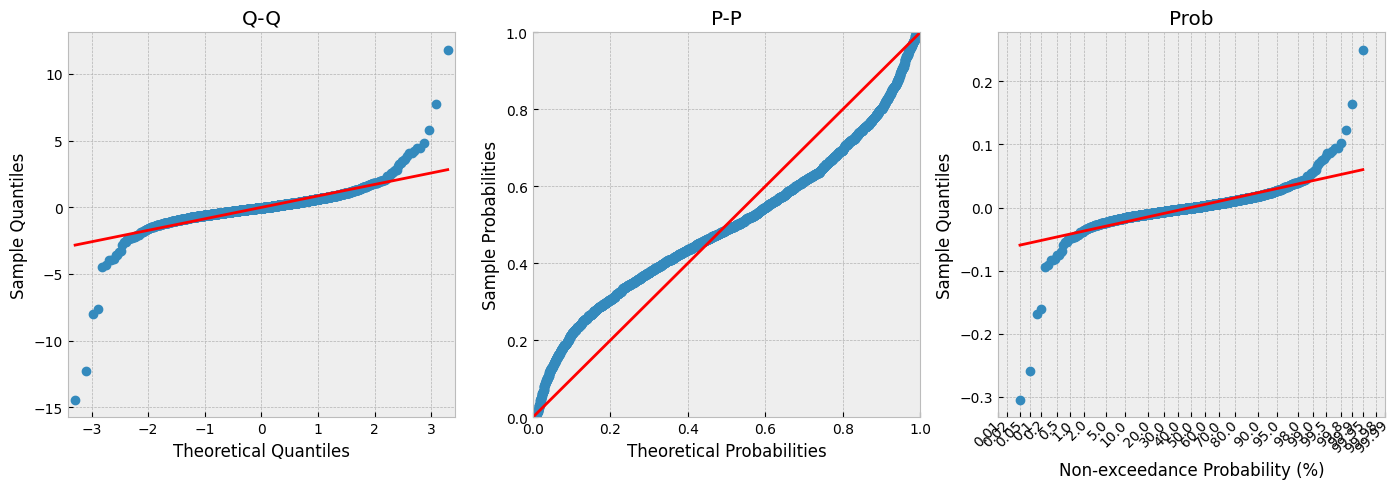

In [11]:
!pip install statsmodels
import statsmodels.graphics.gofplots
pp = statsmodels.graphics.gofplots.ProbPlot(ret, fit=True)

fig = plt.figure(figsize=(17, 5))

plt1 = fig.add_subplot(1,3,1)
plt2 = fig.add_subplot(1,3,2)
plt3 = fig.add_subplot(1,3,3)

pp.qqplot(ax=plt1.axes, line='r')
plt1.set_title('Q-Q')

pp.ppplot(ax=plt2.axes, line='45')
plt2.set_title('P-P')

pp.probplot(ax=plt3.axes, line='r')
plt3.set_title('Prob')

plt.show()

## Риск-метрики

### Value-at-Risk 

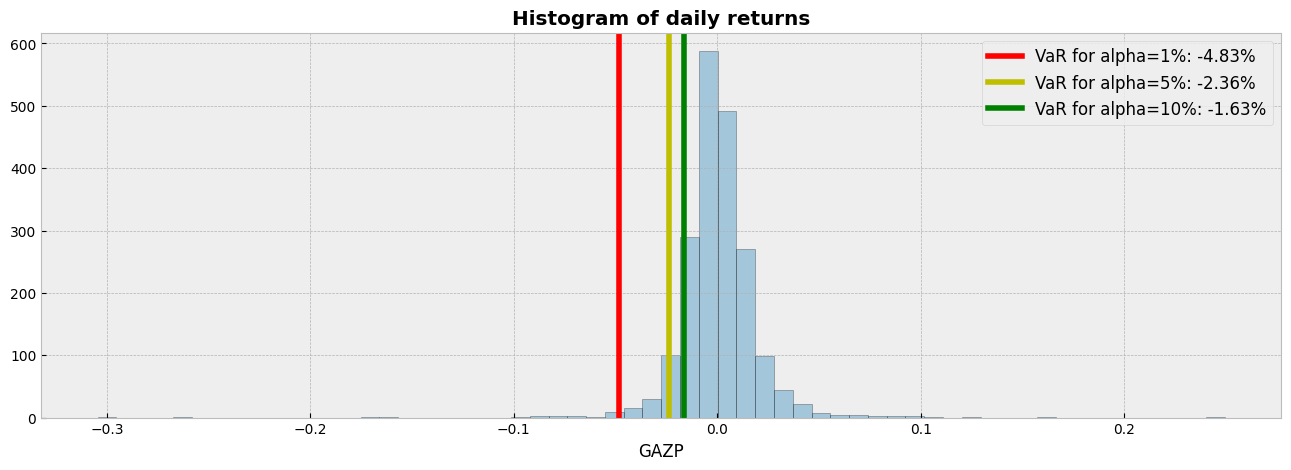

In [12]:
VaR_HS_01 = ret.quantile(0.01)
VaR_HS_05 = ret.quantile(0.05)
VaR_HS_10 = ret.quantile(0.10)

fig = plt.figure(figsize=(16, 5))

sns.distplot(ret, hist=True, kde=False, 
             bins=60,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

plt.axvline(x=VaR_HS_01, linewidth=4, color="r")
plt.axvline(x=VaR_HS_05, linewidth=4, color="y")
plt.axvline(x=VaR_HS_10, linewidth=4, color="g")

plt.title("Histogram of daily returns", weight="bold")

plt.legend(['VaR for alpha=1%: {:.2f}%'.format(100*VaR_HS_01),
            'VaR for alpha=5%: {:.2f}%'.format(100*VaR_HS_05),
            'VaR for alpha=10%: {:.2f}%'.format(100*VaR_HS_10)], fontsize=12)

plt.show()

### Expected Shortfall 

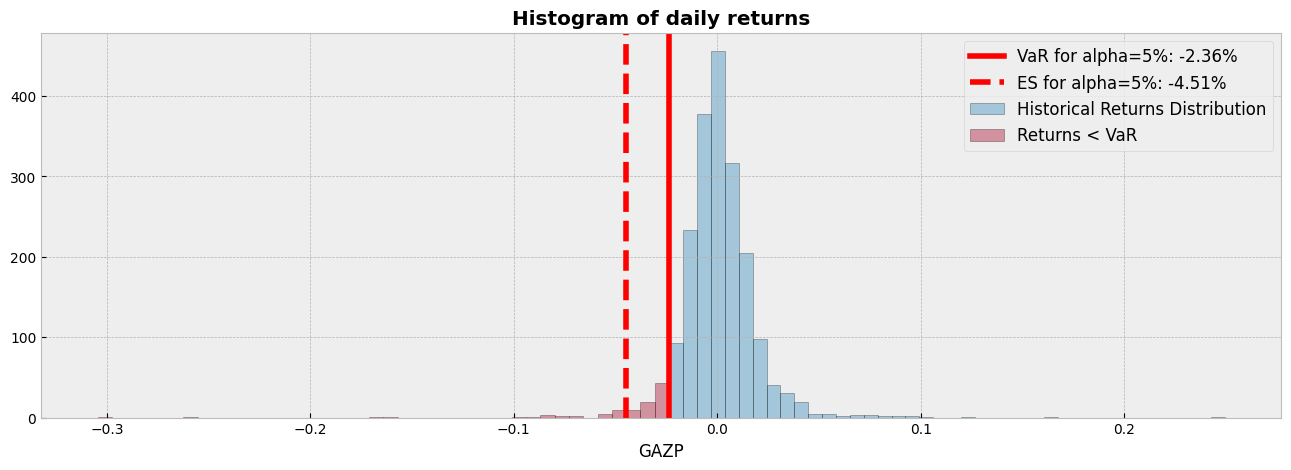

In [13]:
alpha = 0.05

VaR_HS = ret.quantile(alpha)
ES_HS = ret[ret < VaR_HS].mean()

fig = plt.figure(figsize=(16, 5))

sns.distplot(ret[ret >= VaR_HS], hist=True, kde=False, 
             bins=40,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

sns.distplot(ret[ret < VaR_HS], hist=True, kde=False, 
             bins=40,
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

plt.axvline(x=VaR_HS, linewidth=4, color="r")
plt.axvline(ES_HS, linewidth=4, color='red', linestyle='dashed')

plt.title("Histogram of daily returns", weight="bold")
plt.legend(['VaR for alpha=5%: {:.2f}%'.format(100*VaR_HS),
            'ES for alpha=5%: {:.2f}%'.format(100*ES_HS),
            'Historical Returns Distribution', 
            'Returns < VaR'], fontsize=12)

plt.show()

## Различные подходы

### Исторический (Historical simulation)

In [14]:
def calculate_VaR_HS(ret, alpha=0.05):

    return ret.quantile(alpha)

In [15]:
def calc_VaR(r, VaR_fun, L_history=252, level=0.05):
    VaR = np.full(r.size, np.nan)
    
    for i in range(L_history, len(r)):
        history = r[i - L_history: i]
        VaR[i] = VaR_fun(history, level)
        
    return pd.Series(data=VaR, index=r.index, name=VaR_fun.__name__)

In [16]:
VaR_HS = calc_VaR(ret, calculate_VaR_HS, L_history=252, level=alpha)

VaR_HS

datetime
2016-03-14         NaN
2016-03-15         NaN
2016-03-16         NaN
2016-03-17         NaN
2016-03-18         NaN
                ...   
2024-03-06   -0.015719
2024-03-07   -0.015719
2024-03-11   -0.015719
2024-03-12   -0.015719
2024-03-13   -0.015719
Name: calculate_VaR_HS, Length: 1999, dtype: float64

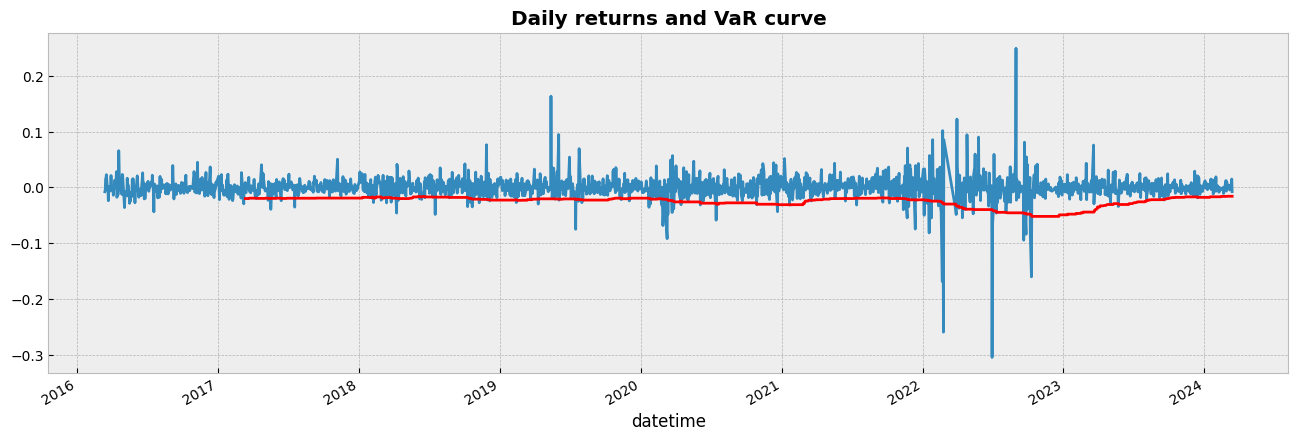

In [17]:
fig = plt.figure(figsize=(16, 5))

ret.plot()
VaR_HS.plot(color='r')

plt.title("Daily returns and VaR curve", weight="bold")

plt.show()

### Параметрический (Parametric estimation)

#### Нормальное распределение

In [18]:
import scipy.stats as ss

params_norm = ss.norm.fit(ret)
norm_mean, norm_sigma = params_norm

VaR_norm = ss.norm.ppf(alpha, norm_mean, norm_sigma)
ES_norm = ss.norm.expect(loc=norm_mean, scale=norm_sigma, ub=VaR_norm, conditional=True)

print('Estimated parameters: mean={:.2f}, scale={:.2f}'.format(norm_mean, norm_sigma))
print('Value-at-Risk: {:.2f}%'.format(100*VaR_norm))
print('Expected Shortfall: {:.2f}%'.format(100*ES_norm))

Estimated parameters: mean=0.00, scale=0.02
Value-at-Risk: -3.44%
Expected Shortfall: -4.32%


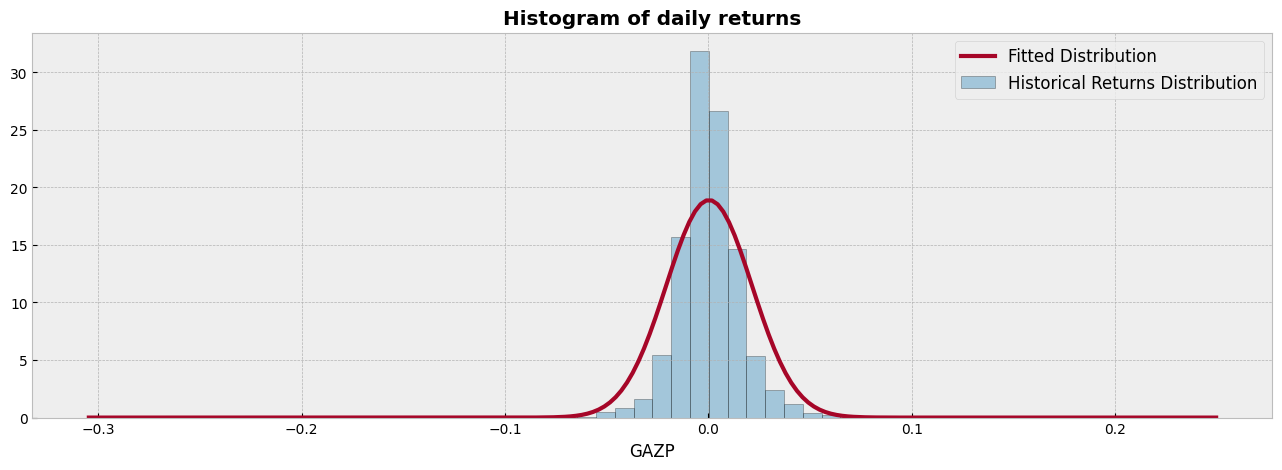

In [19]:
fig = plt.figure(figsize=(16, 5))

x = np.linspace(ret.min(), ret.max(), 200)

y_pdf = ss.norm.pdf(x, *params_norm)

sns.distplot(ret, hist=True, kde=False, 
             bins=60, norm_hist=True,
             hist_kws={'edgecolor':'black'})
plt.plot(x, y_pdf, linewidth=3)

plt.title("Histogram of daily returns", weight="bold")
plt.legend(['Fitted Distribution', 'Historical Returns Distribution'], fontsize=12)

plt.show()

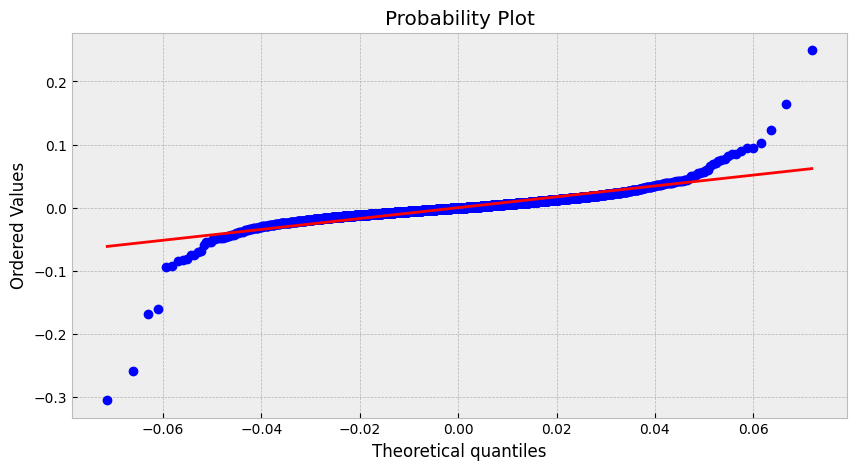

In [20]:
fig = plt.figure(figsize=(10, 5))
ss.probplot(ret, dist=ss.norm(*params_norm), plot=plt)
plt.show()

#### Распределение Стьюдента

In [21]:
params_t = ss.t.fit(ret)
t_df, t_mean, t_sigma = params_t

VaR_t = ss.t.ppf(alpha, t_df, t_mean, t_sigma)
ES_t = ss.t.expect(args=(t_df,), loc=t_mean, scale=t_sigma, ub=VaR_t, conditional=True)

print('Estimated parameters: df={:.2f}, mean={:.2f}, scale={:.2f}'.format(t_df, t_mean, t_sigma))
print('Value-at-Risk: {:.2f}%'.format(100*VaR_t))
print('Expected Shortfall: {:.2f}%'.format(100*ES_t))

Estimated parameters: df=2.70, mean=-0.00, scale=0.01
Value-at-Risk: -2.60%
Expected Shortfall: -4.48%


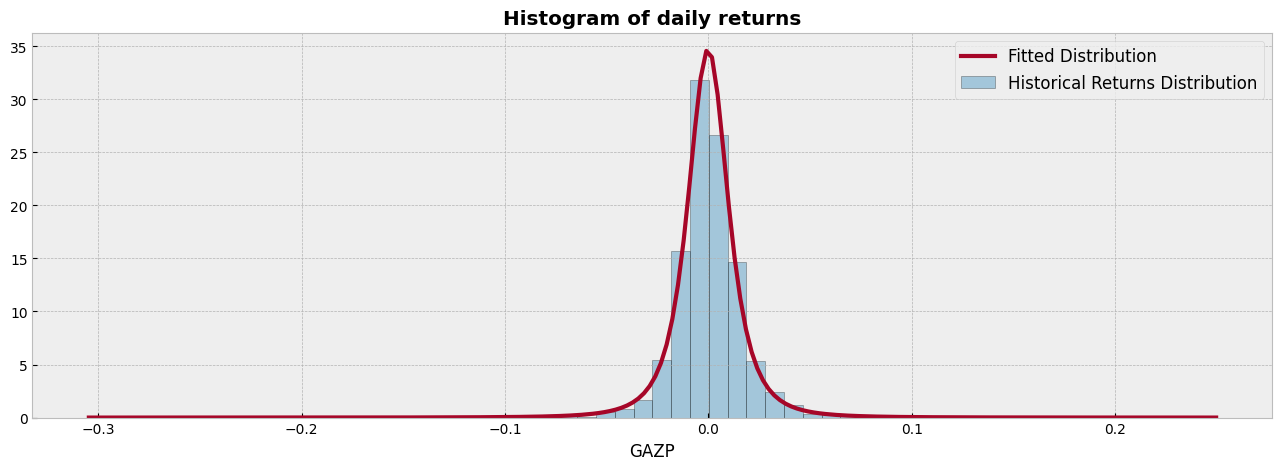

In [22]:
fig = plt.figure(figsize=(16, 5))

x = np.linspace(ret.min(), ret.max(), 200)

y_pdf = ss.t.pdf(x, *params_t)

sns.distplot(ret, hist=True, kde=False, 
             bins=60, norm_hist=True,
             hist_kws={'edgecolor':'black'})
plt.plot(x, y_pdf, linewidth=3)

plt.title("Histogram of daily returns", weight="bold")
plt.legend(['Fitted Distribution', 'Historical Returns Distribution'], fontsize=12)


plt.show()

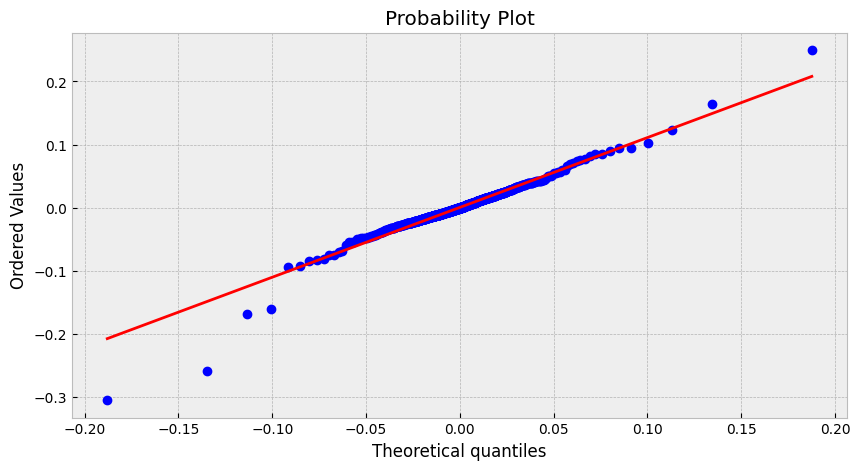

In [23]:
fig = plt.figure(figsize=(10, 5))
ss.probplot(ret, dist=ss.t(*params_t), plot=plt)
plt.show()

In [24]:
def calculate_VaR_normal(ret, alpha=0.05):

    params_norm = ss.norm.fit(ret)
    
    return ss.norm.ppf(alpha, *params_norm)


def calculate_VaR_t(ret, alpha=0.05):

    params_t = ss.t.fit(ret)
    
    return ss.t.ppf(alpha, *params_t)

In [25]:
VaR_norm = calc_VaR(ret, calculate_VaR_normal, L_history=252, level=alpha)

VaR_t = calc_VaR(ret, calculate_VaR_t, L_history=252, level=alpha)

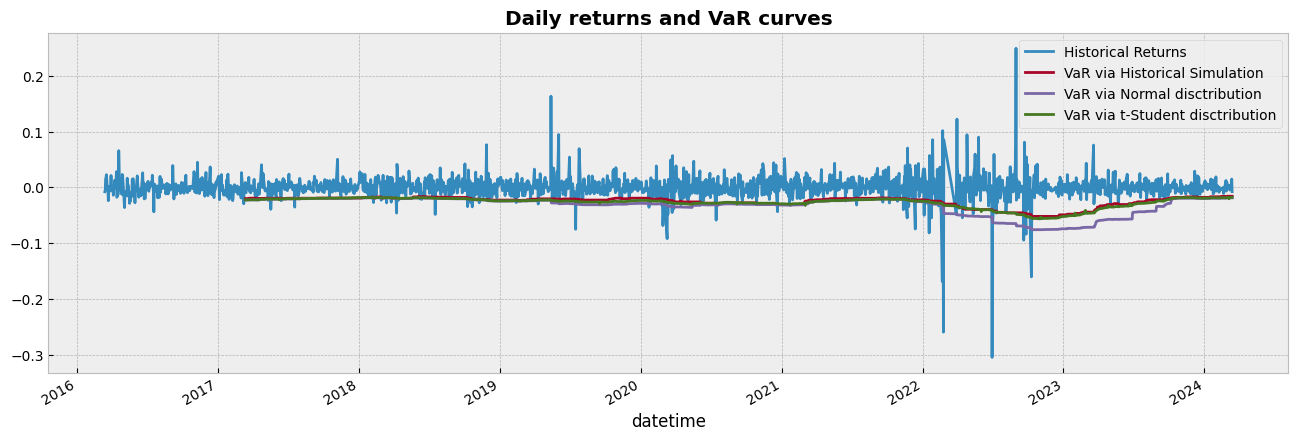

In [26]:
fig = plt.figure(figsize=(16, 5))

ret.plot()
VaR_HS.plot()
VaR_norm.plot()
VaR_t.plot()

plt.title("Daily returns and VaR curves", weight="bold")

plt.legend(['Historical Returns',
            'VaR via Historical Simulation',
            'VaR via Normal disctribution',
            'VaR via t-Student disctribution'])

plt.show()

### Теория экстремальных значений

#### Блочные максимумы (Block maxima) и Обобщенное распределение экстремальных значений (Generalized Extreme Value Distribution (GEV))


Семплируем потери по периодам (напр. неделя, месяц и т.д.)

In [27]:
# maximas = ret.resample('W').min().fillna(method = 'bfill')

maximas = ret.resample('W').min()
maximas = maximas.bfill()
print(maximas.head())

datetime
2016-03-20   -0.007623
2016-03-27   -0.023738
2016-04-03   -0.006437
2016-04-10   -0.013936
2016-04-17   -0.017568
Freq: W-SUN, Name: GAZP, dtype: float64


In [28]:
ret

datetime
2016-03-14   -0.007623
2016-03-15   -0.004609
2016-03-16    0.015504
2016-03-17    0.017409
2016-03-18    0.022951
                ...   
2024-03-06    0.004162
2024-03-07   -0.004578
2024-03-11   -0.002175
2024-03-12    0.015135
2024-03-13   -0.007485
Name: GAZP, Length: 1999, dtype: float64

In [29]:
maximas

datetime
2016-03-20   -0.007623
2016-03-27   -0.023738
2016-04-03   -0.006437
2016-04-10   -0.013936
2016-04-17   -0.017568
                ...   
2024-02-18   -0.004533
2024-02-25   -0.010791
2024-03-03   -0.006559
2024-03-10   -0.004578
2024-03-17   -0.007485
Freq: W-SUN, Name: GAZP, Length: 418, dtype: float64

In [30]:
params_genextreme = ss.genextreme.fit(maximas)
c, loc, scale = params_genextreme
xi = -c

VaR_genextreme = loc + scale / xi * (1 - (-5*np.log(1-alpha)) ** (-xi) )
# VaR_genextreme = ss.genextreme.ppf(alpha**(-5), *params_genextreme)


print('Estimated parameters: c={:.2f}, mean={:.2f}, scale={:.2f}'.format(c, loc, scale))
print('Value-at-Risk: {:.2f}%'.format(100*VaR_genextreme))
# print('Expected Shortfall: {:.2f}%'.format(100*ES_genpareto))

Estimated parameters: c=0.59, mean=-0.02, scale=0.02
Value-at-Risk: -4.48%


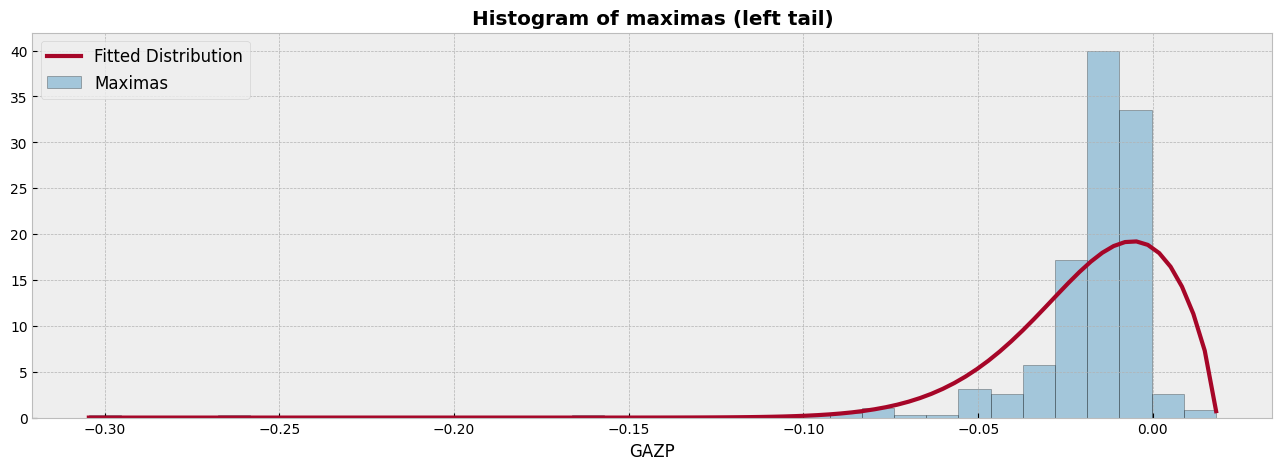

In [31]:
fig = plt.figure(figsize=(16, 5))

x = np.linspace(maximas.min(), maximas.max(), 100)

y_pdf = ss.genextreme.pdf(x, *params_genextreme)

sns.distplot(maximas, hist=True, kde=False, 
             bins=35, norm_hist=True,
             hist_kws={'edgecolor':'black'})
plt.plot(x, y_pdf, linewidth=3)

plt.title("Histogram of maximas (left tail)", weight="bold")
plt.legend(['Fitted Distribution', 'Maximas'], fontsize=12)

plt.show()

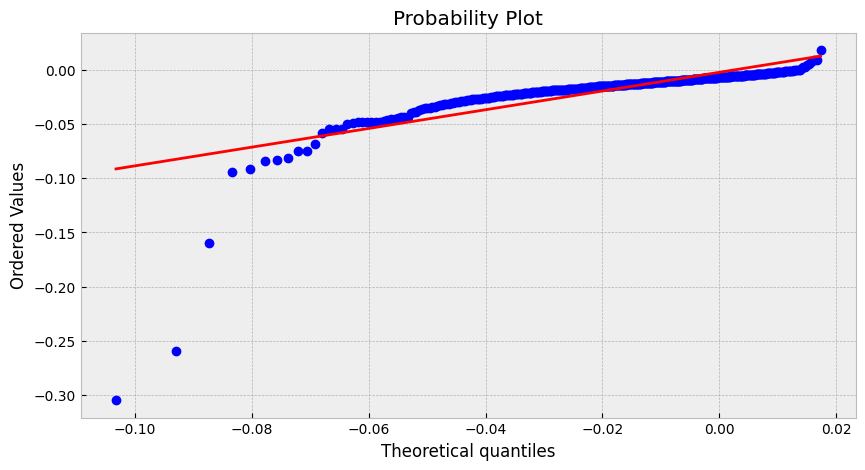

In [32]:
fig = plt.figure(figsize=(10, 5))
ss.probplot(maximas, dist=ss.genextreme(*params_genextreme), plot=plt)
plt.show()

#### Распределение сверх порогового значения (Excess Distribution Over a Threshold)

In [33]:
u = ret.quantile(0.2)

print(u)

ret_tail = ret[ret <= u]

-0.01047716707188795


In [34]:
params_genpareto = ss.genpareto.fit(-ret_tail, loc=0)
c, loc, scale = params_genpareto

VaR_genpareto = u - scale / c * ((alpha/(ret <= u).mean())**(-c) - 1)
ES_genpareto = VaR_genpareto / (1 - c) - (scale - c*u) / (1 - c)

print('Estimated parameters: c={:.2f}, mean={:.2f}, scale={:.2f}'.format(c, loc, scale))
print('Value-at-Risk: {:.2f}%'.format(100*VaR_genpareto))
print('Expected Shortfall: {:.2f}%'.format(100*ES_genpareto))

Estimated parameters: c=0.39, mean=0.01, scale=0.01
Value-at-Risk: -2.38%
Expected Shortfall: -5.76%


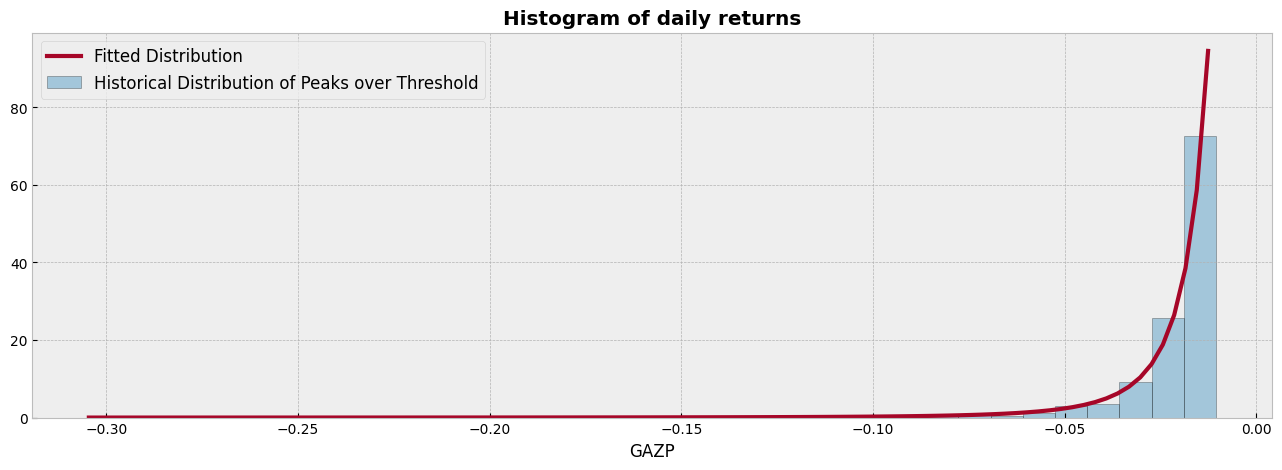

In [35]:
fig = plt.figure(figsize=(16, 5))

x = np.linspace(ret_tail.min(), ret_tail.max()*1.2, 100)

y_pdf = ss.genpareto.pdf(-x, *params_genpareto)

sns.distplot(ret_tail, hist=True, kde=False, 
             bins=35, norm_hist=True,
             hist_kws={'edgecolor':'black'})
plt.plot(x, y_pdf, linewidth=3)

plt.title("Histogram of daily returns", weight="bold")
plt.legend(['Fitted Distribution', 'Historical Distribution of Peaks over Threshold'], fontsize=12)

plt.show()

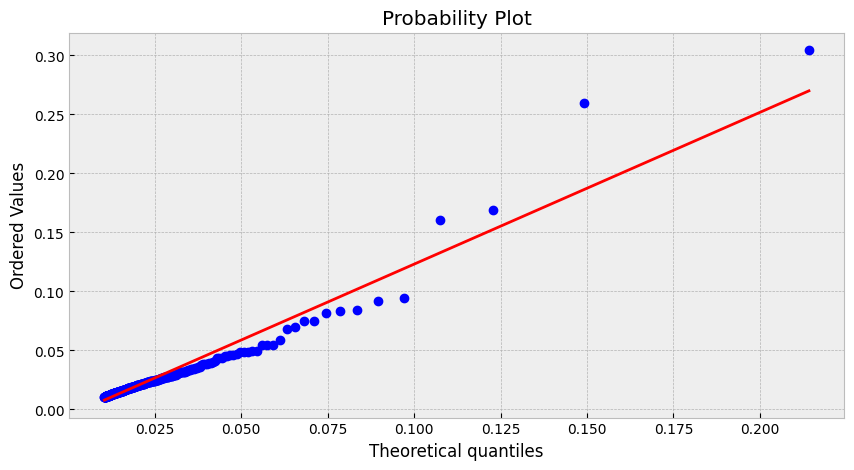

In [36]:
fig = plt.figure(figsize=(10, 5))
ss.probplot(-ret_tail, dist=ss.genpareto(*params_genpareto), plot=plt)
plt.show()

In [37]:
def calculate_VaR_pot(ret, alpha=0.05):
    
    u = ret.quantile(0.2)
    ret_tail = ret[ret <= u]

    c, loc, scale = ss.genpareto.fit(-ret_tail, loc=0)
    
    return u - scale / c * ((alpha/(ret <= u).mean())**(-c) - 1)


def calculate_VaR_maximas(ret, alpha=0.05):
    
    maximas = ret.resample('W').min().bfill()
    
    params_genextreme = ss.genextreme.fit(maximas)
    c, loc, scale = params_genextreme
    xi = -c

    return loc + scale / xi * (1 - (-5*np.log(1-alpha)) ** (-xi) )

In [38]:
VaR_pot = calc_VaR(ret, calculate_VaR_pot, L_history=252, level=alpha)
VaR_maximas = calc_VaR(ret, calculate_VaR_maximas, L_history=252, level=alpha)

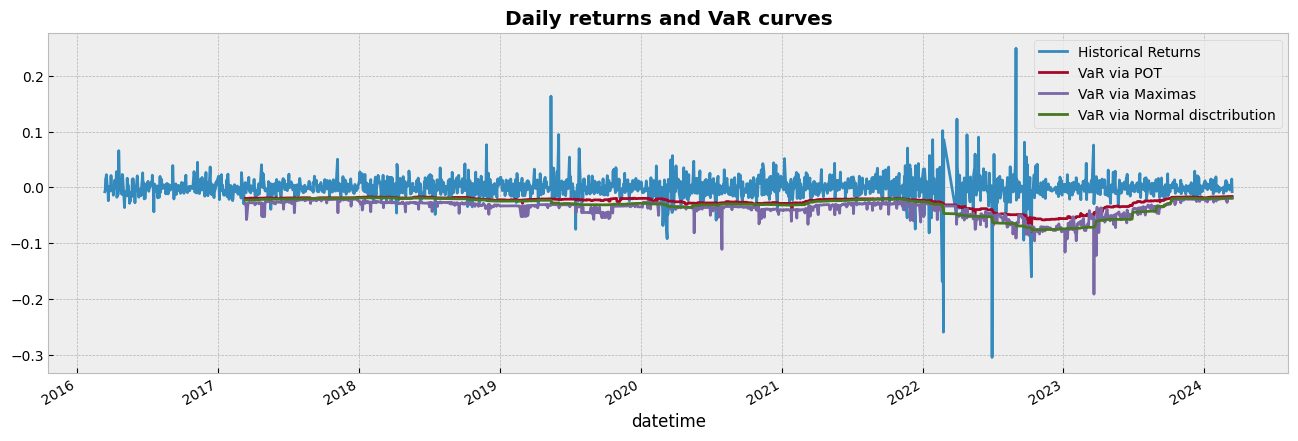

In [39]:
fig = plt.figure(figsize=(16, 5))

ret.plot()
VaR_pot.plot()
VaR_maximas.plot()
VaR_norm.plot()

plt.title("Daily returns and VaR curves", weight="bold")

plt.legend(['Historical Returns',
            'VaR via POT',
            'VaR via Maximas', 
           'VaR via Normal disctribution'])

plt.show()

### GARCH модели

#### GARCH с параметрическим распределением остатков

[Документация arch](https://arch.readthedocs.io/en/latest/univariate/introduction.html)

In [40]:
!pip install arch


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Обучим модель

In [41]:
from arch import arch_model 
mdl = arch_model(100 * ret) # согласно документации
res = mdl.fit()
res

Iteration:      1,   Func. Count:      6,   Neg. LLF: 190171.0502346108
Iteration:      2,   Func. Count:     14,   Neg. LLF: 10580.726800955583
Iteration:      3,   Func. Count:     22,   Neg. LLF: 3935.4726861573063
Iteration:      4,   Func. Count:     27,   Neg. LLF: 3943.7038814861717
Iteration:      5,   Func. Count:     33,   Neg. LLF: 5456.081757910932
Iteration:      6,   Func. Count:     40,   Neg. LLF: 4495.273936541213
Iteration:      7,   Func. Count:     47,   Neg. LLF: 4520.984762985518
Iteration:      8,   Func. Count:     53,   Neg. LLF: 3931.503600986088
Iteration:      9,   Func. Count:     59,   Neg. LLF: 3919.9549713970882
Iteration:     10,   Func. Count:     65,   Neg. LLF: 3918.005594294279
Iteration:     11,   Func. Count:     71,   Neg. LLF: 3917.0495028422406
Iteration:     12,   Func. Count:     76,   Neg. LLF: 3917.048919547876
Iteration:     13,   Func. Count:     81,   Neg. LLF: 3917.0489169348075
Iteration:     14,   Func. Count:     85,   Neg. LLF: 3917

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   GAZP   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3917.05
Distribution:                  Normal   AIC:                           7842.10
Method:            Maximum Likelihood   BIC:                           7864.50
                                        No. Observations:                 1999
Date:                Thu, Sep 24 2026   Df Residuals:                     1998
Time:                        17:59:18   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0511  3.229e-02      1.582      0.114 [-1.22

In [42]:
dist = 'skewstudent'

mdl = arch_model(100 * ret,
                    mean='HARX', lags=1, # mean = Constant, ARX, HARX + the number of lags
                    vol='Garch', p=1, o=1, q=1, # vol = Garch, EGARCH, HARCH + the number of lags
                    dist=dist) # dist = Normal, t, skewstudent, ged

res = mdl.fit()
res

Iteration:      1,   Func. Count:     10,   Neg. LLF: 46112.02824568683
Iteration:      2,   Func. Count:     22,   Neg. LLF: 96692.48050306151
Iteration:      3,   Func. Count:     33,   Neg. LLF: 126990.19751732112
Iteration:      4,   Func. Count:     44,   Neg. LLF: 88118.67253120162
Iteration:      5,   Func. Count:     55,   Neg. LLF: 42183.487500977804
Iteration:      6,   Func. Count:     66,   Neg. LLF: 7686.8425023775435
Iteration:      7,   Func. Count:     77,   Neg. LLF: 5884.341313614648
Iteration:      8,   Func. Count:     88,   Neg. LLF: 5358.312546567577
Iteration:      9,   Func. Count:     99,   Neg. LLF: 5230.506130766842
Iteration:     10,   Func. Count:    110,   Neg. LLF: 3703.625290568656
Iteration:     11,   Func. Count:    121,   Neg. LLF: 3619.308780746782
Iteration:     12,   Func. Count:    130,   Neg. LLF: 3619.2901310203733
Iteration:     13,   Func. Count:    139,   Neg. LLF: 3619.2887085909906
Iteration:     14,   Func. Count:    148,   Neg. LLF: 3619.

                              HAR - GJR-GARCH Model Results                              
Dep. Variable:                              GAZP   R-squared:                       0.000
Mean Model:                                  HAR   Adj. R-squared:                 -0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -3619.29
Distribution:      Standardized Skew Student's t   AIC:                           7254.57
Method:                       Maximum Likelihood   BIC:                           7299.37
                                                   No. Observations:                 1998
Date:                           Thu, Sep 24 2026   Df Residuals:                     1996
Time:                                   17:59:19   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------

Рассмотрим условную волатильность и стандартизированные остатки 

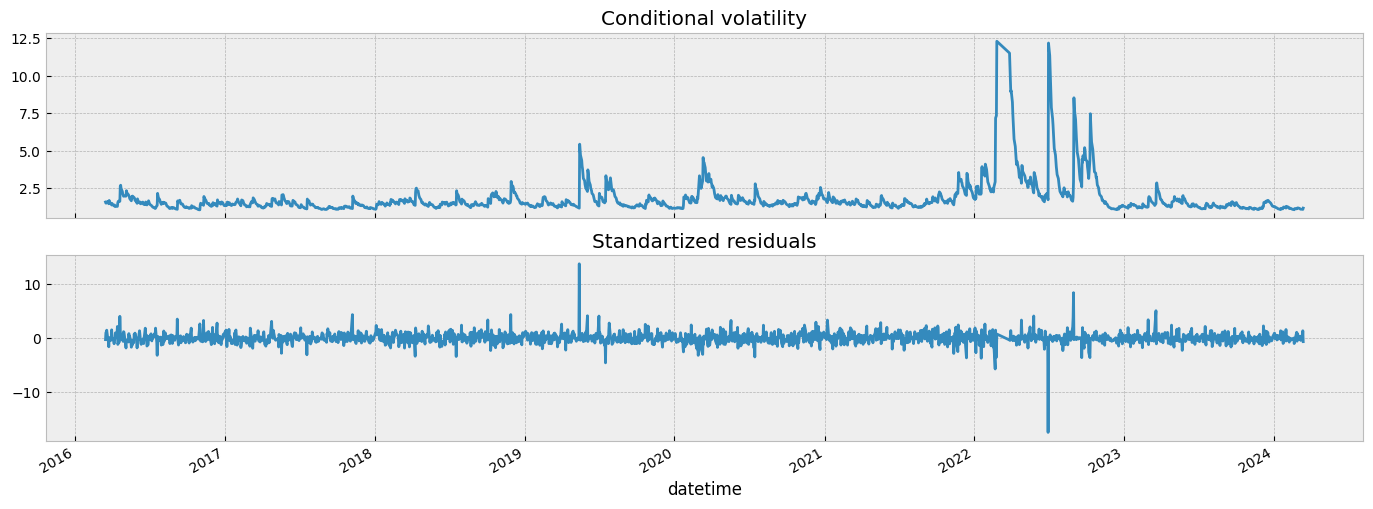

In [43]:
fig = plt.figure(figsize=(17, 6))

plt1 = fig.add_subplot(2,1,1)
plt2 = fig.add_subplot(2,1,2)

res.conditional_volatility.plot(ax=plt1.axes)
plt1.set_title('Conditional volatility')

(res.resid / res.conditional_volatility).plot(ax=plt2.axes)
plt2.set_title('Standartized residuals')

for ax in fig.get_axes():
    ax.label_outer()

plt.show()

Предсказываем условное среднее и дисперсию

In [44]:
my_forecast = res.forecast(horizon=5)

print(my_forecast.mean.tail(4))
print(my_forecast.variance.tail(4))

                 h.1       h.2       h.3       h.4       h.5
datetime                                                    
2024-03-13  0.030436  0.041432  0.041587  0.041589  0.041589
                h.1       h.2       h.3       h.4       h.5
datetime                                                   
2024-03-13  1.46286  1.580062  1.691174  1.796754  1.897075


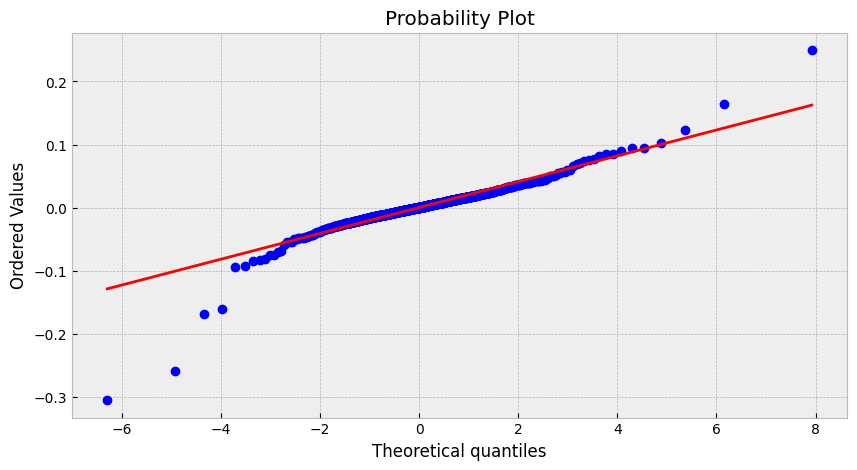

In [45]:
fig = plt.figure(figsize=(10, 5))
ss.probplot(ret, dist=mdl.distribution, sparams=(res.params[-2:],), plot=plt)
plt.show()

#### Filtered Historical Simulation

In [ ]:
# # обучаем модель с нормальным распределением остатков

mdl = arch_model(100 * ret,
                      mean='Constant',
                      vol='Garch', p=1, o=0, q=1, # Стандартный GARCH(1,1)
                      dist='normal')

res = mdl.fit(disp='off')

# получаем стандартизированные остатки
stand_residuals = res.resid / res.conditional_volatility
stand_residuals = stand_residuals.dropna()


# предсказываем средднее и десперсию на один шаг вперед
forecasts = res.forecast(horizon=1)
cond_mean = float(forecasts.mean.iloc[-1].values[0])
cond_var = float(forecasts.variance.iloc[-1].values[0])


# получаем предсказанные условные доходности
conditional_sr = cond_mean + np.sqrt(cond_var) * stand_residuals
conditional_sr = conditional_sr / 100


# считаем VaR как квантиль
VaR_FHS = conditional_sr.quantile(alpha)

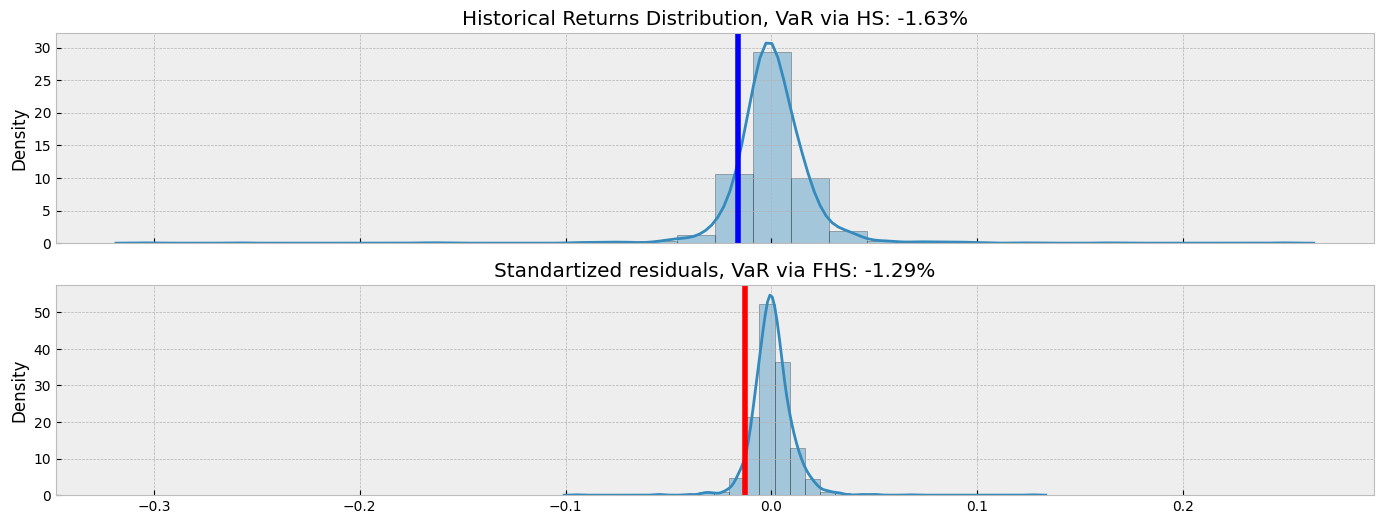

In [47]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(17, 6))

sns.distplot(ret, hist=True, kde=True, 
             bins=30, norm_hist=True,
             hist_kws={'edgecolor':'black'}, ax=ax[0])
ax[0].set_title('Historical Returns Distribution, VaR via HS: {:.2f}%'.format(100*VaR_HS_10))
ax[0].axvline(x=VaR_HS_10, linewidth=4, color="b")

sns.distplot(conditional_sr, hist=True, kde=True, 
             bins=30, norm_hist=True,
             hist_kws={'edgecolor':'black'}, ax=ax[1])
ax[1].set_title('Standartized residuals, VaR via FHS: {:.2f}%'.format(100*VaR_FHS))
ax[1].axvline(x=VaR_FHS, linewidth=4, color="r")

for ax in fig.get_axes():
    ax.label_outer()

plt.show()

In [ ]:
def calculate_VaR_garch(returns, alpha):
    
    scaling_const = 10.0 / returns.std()

    dist = 'skewstudent'
    am = arch_model(scaling_const * returns,
                    mean='HARX', lags=1, # mean = Constant, ARX, HARX + the number of lags
                    vol='Garch', p=1, o=1, q=1, # vol = Garch, EGARCH, HARCH + the number of lags
                    dist=dist) # dist = Normal, t, skewstudent, ged

    res = am.fit(update_freq=0, disp='off')

    forecasts = res.forecast(horizon=1)

    cond_mean = float(forecasts.mean.iloc[-1].values[0])
    cond_var = float(forecasts.variance.iloc[-1].values[0])

    if dist == 'Normal':
        q = am.distribution.ppf(alpha)
    elif dist == 't' or dist == 'ged':
        q = am.distribution.ppf(alpha, res.params[-1:])
    elif dist == 'skewstudent':
        q = am.distribution.ppf(alpha, res.params[-2:])

    return_garch_forecast = cond_mean / scaling_const
    VaR_garch_forecast = (cond_mean + np.sqrt(cond_var) * q) / scaling_const

    return VaR_garch_forecast


def calculate_VaR_FHS(returns, alpha):
    
    scaling_const = 10.0 / returns.std()

    mdl = arch_model(scaling_const * returns,
                    mean='HARX', lags=1, # mean = Constant, ARX, HARX + the number of lags
                    vol='Garch', p=1, o=1, q=1, # vol = Garch, EGARCH, HARCH + the number of lags
                    dist='normal')

    res = mdl.fit(disp='off')

   # получаем стандартизированные остатки
    stand_residuals = res.resid / res.conditional_volatility
    stand_residuals = stand_residuals.dropna()


   # предсказываем средднее и десперсию на один шаг вперед
    forecasts = res.forecast(horizon=1)
    cond_mean = float(forecasts.mean.iloc[-1].values[0])
    cond_var = float(forecasts.variance.iloc[-1].values[0])

    # получаем предсказанные условные доходности
    conditional_sr = cond_mean + np.sqrt(cond_var) * stand_residuals
    conditional_sr = conditional_sr / scaling_const

    # считаем VaR как квантиль
    VaR_FHS = conditional_sr.quantile(alpha)

    return VaR_FHS

In [49]:
VaR_garch = calc_VaR(ret, calculate_VaR_garch, L_history=252, level=alpha)
VaR_FHS = calc_VaR(ret, calculate_VaR_FHS, L_history=252, level=alpha)

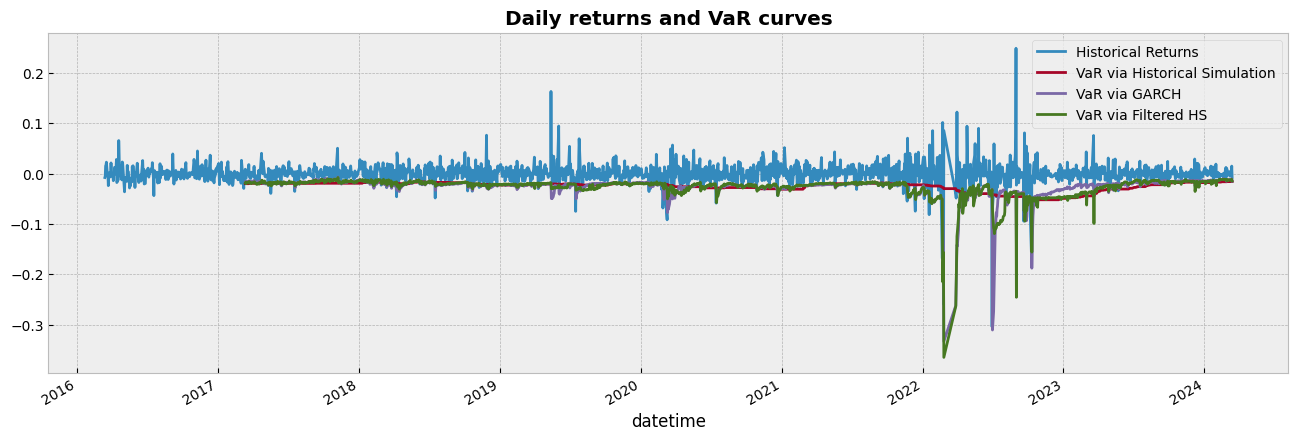

In [50]:
fig = plt.figure(figsize=(16, 5))

ret.plot()
VaR_HS.plot()
# VaR_t.plot()
VaR_garch.plot()
VaR_FHS.plot()

plt.title("Daily returns and VaR curves", weight="bold")

plt.legend(['Historical Returns',
            'VaR via Historical Simulation',
           'VaR via GARCH',
           'VaR via Filtered HS'])

plt.show()

## Бектестирование VaR

[Overview of VaR Backtesting](https://www.mathworks.com/help/risk/overview-of-var-backtesting.html)

In [51]:
def calc_hits(returns, VaRs):
    return ((VaRs - returns).dropna() > 0).values

In [52]:
hits = calc_hits(ret, VaR_t)
hits

array([False, False, False, ..., False, False, False], shape=(1747,))

In [53]:
hits.mean()

np.float64(0.04350314825414997)

In [54]:
def zone(p):
    if p > 0.05:
        return 'green'
    elif p > 0.0001:
        return 'yellow'
    else:
        return 'red'

In [55]:
def backtest_VaR(r, VaR, level, L=None):
    if L is None:
        L = (~VaR.isna()).to_numpy().nonzero()[0][0];
    r = r[L:]
    VaR = VaR[L:]
    
    hits = calc_hits(r, VaR)    
    
    # p_value_two_sided = ss.binom_test(sum(hits), len(hits), 1-level, alternative = 'two-sided')
    # p_value_conservative = ss.binom_test(sum(hits), len(hits), 1-level, alternative = 'greater')
    res_two = ss.binomtest(int(sum(hits)), len(hits), 1-level, alternative='two-sided')
    p_value_two_sided = res_two.pvalue

    res_one = ss.binomtest(int(sum(hits)), len(hits), 1-level, alternative='greater')
    p_value_conservative = res_one.pvalue
    
    print(f'Backtesting {VaR.name}:')
    print(f'The proportion of hits is {(sum(hits)/len(hits))*100:.3}% instead of expected {(1-level)*100:.3}%')
    print(f'Two-sided p-val {p_value_two_sided:.3}, one-sided: {p_value_conservative:.3}')
    print(f'{zone(p_value_two_sided)} zone\n')

In [56]:
backtest_VaR(ret, VaR_HS, 1-alpha)
backtest_VaR(ret, VaR_t, 1-alpha)
backtest_VaR(ret, VaR_garch, 1-alpha)
backtest_VaR(ret, VaR_FHS, 1-alpha)

Backtesting calculate_VaR_HS:
The proportion of hits is 5.55% instead of expected 5.0%
Two-sided p-val 0.297, one-sided: 0.158
green zone

Backtesting calculate_VaR_t:
The proportion of hits is 4.35% instead of expected 5.0%
Two-sided p-val 0.227, one-sided: 0.905
green zone

Backtesting calculate_VaR_garch:
The proportion of hits is 4.69% instead of expected 5.0%
Two-sided p-val 0.621, one-sided: 0.736
green zone

Backtesting calculate_VaR_FHS:
The proportion of hits is 5.09% instead of expected 5.0%
Two-sided p-val 0.826, one-sided: 0.443
green zone



## Реализация моделей

### GARCH,  FIGARCH(1,1,2)

In [57]:
from scipy.stats import norminvgauss, t, genpareto
from arch import arch_model

def calculate_VaR_GARCH_Student_FIGARCH(returns, alpha, use_figarch=False):
    scaled_ret = 100 * returns

    if use_figarch:
        try:
            am = arch_model(scaled_ret, mean='Constant', vol='FIGARCH', p=1, d=1, q=1, dist='t')
        except:
            # если FIGARCH не не сходится, "откатываемся" на GARCH
            am = arch_model(scaled_ret, mean='Constant', vol='Garch', p=1, o=0, q=1, dist='t')
    else:
        am = arch_model(scaled_ret, mean='Constant', vol='Garch', p=1, o=0, q=1, dist='t') #GARCH(1,1) с константным средним и Стьюдентом
    res = am.fit(update_freq=0, disp='off')

    # прогноз
    forecasts = res.forecast(horizon=1)
    cond_mean = float(forecasts.mean.iloc[-1].values[0])
    cond_var = float(forecasts.variance.iloc[-1].values[0])

    nu = res.params['nu'] #степени свободы
    z_quantile = t.ppf(alpha, df=nu) #квантиль Стьюдента
    VaR_val = (cond_mean + np.sqrt(cond_var) * z_quantile) / 100.0

    return VaR_val


In [58]:
def calc_VaR_GARCH_Student(returns, alpha):
    return calculate_VaR_GARCH_Student_FIGARCH(returns, alpha, use_figarch=False)

def calc_VaR_FIGARCH(returns, alpha):
    return calculate_VaR_GARCH_Student_FIGARCH(returns, alpha, use_figarch=True)

### Обратное Гауссовское распределение

In [59]:
def calculate_VaR_NIG(returns, alpha):
    data_norm = (returns - returns.mean()) / returns.std()

    try:
        params = norminvgauss.fit(data_norm) #параметры (a, b, loc, scale)
        nig_quantile = norminvgauss.ppf(alpha, *params) #квантиль для нормализованных данных
        VaR_val = returns.mean() + returns.std() * nig_quantile
        return VaR_val
    except:
        return np.nan


### Комбинация GARCH и EV

In [60]:
def calculate_VaR_GARCH_EVT(returns, alpha):
    scaled_ret = 100 * returns

# обучаем модель
    am = arch_model(scaled_ret, mean='Constant', vol='Garch', p=1, o=0, q=1, dist='normal')
    res = am.fit(update_freq=0, disp='off')

# получаем стандартизированные остатки
    std_resid = res.resid / res.conditional_volatility
    std_resid = std_resid.dropna()

    u = std_resid.quantile(0.2) # порог в 20%
    tail_data = std_resid[std_resid <= u]

    if len(tail_data) < 5:
        return np.nan

    c, loc, scale = genpareto.fit(-tail_data, loc=0)

# прогноз волатильности на след день
    forecasts = res.forecast(horizon=1)
    cond_mean = float(forecasts.mean.iloc[-1].values[0]) / 100.0
    cond_std = np.sqrt(float(forecasts.variance.iloc[-1].values[0])) / 100.0

# VaR для стандартизированных остатков (через формулу РОТ)
    prob_exceedance = (std_resid <= u).mean()

    if abs(c) < 1e-6: # Если c близко к 0
        z_var = u - scale * np.log(alpha / prob_exceedance)
    else:
        z_var = u - scale / c * ((alpha / prob_exceedance)**(-c) - 1)

# итоговый VaR
    VaR_total = cond_mean + cond_std * z_var
    return VaR_total

### Бектестинг

In [61]:
# расчет кривых VaR
VaR_GARCH_Student = calc_VaR(ret, calc_VaR_GARCH_Student, L_history=252, level=alpha)
VaR_FIGARCH = calc_VaR(ret, calc_VaR_FIGARCH, L_history=252, level=alpha)
VaR_NIG = calc_VaR(ret, calculate_VaR_NIG, L_history=252, level=alpha)
VaR_GARCH_EVT = calc_VaR(ret, calculate_VaR_GARCH_EVT, L_history=252, level=alpha)

# бектестинг моделей
backtest_VaR(ret, VaR_GARCH_Student, 1-alpha)
backtest_VaR(ret, VaR_FIGARCH, 1-alpha)
backtest_VaR(ret, VaR_NIG, 1-alpha)
backtest_VaR(ret, VaR_GARCH_EVT, 1-alpha)

Backtesting calc_VaR_GARCH_Student:
The proportion of hits is 1.95% instead of expected 5.0%
Two-sided p-val 6.36e-11, one-sided: 1.0
red zone

Backtesting calc_VaR_FIGARCH:
The proportion of hits is 1.95% instead of expected 5.0%
Two-sided p-val 6.36e-11, one-sided: 1.0
red zone

Backtesting calculate_VaR_NIG:
The proportion of hits is 4.87% instead of expected 5.0%
Two-sided p-val 0.869, one-sided: 0.617
green zone

Backtesting calculate_VaR_GARCH_EVT:
The proportion of hits is 4.58% instead of expected 5.0%
Two-sided p-val 0.475, one-sided: 0.804
green zone



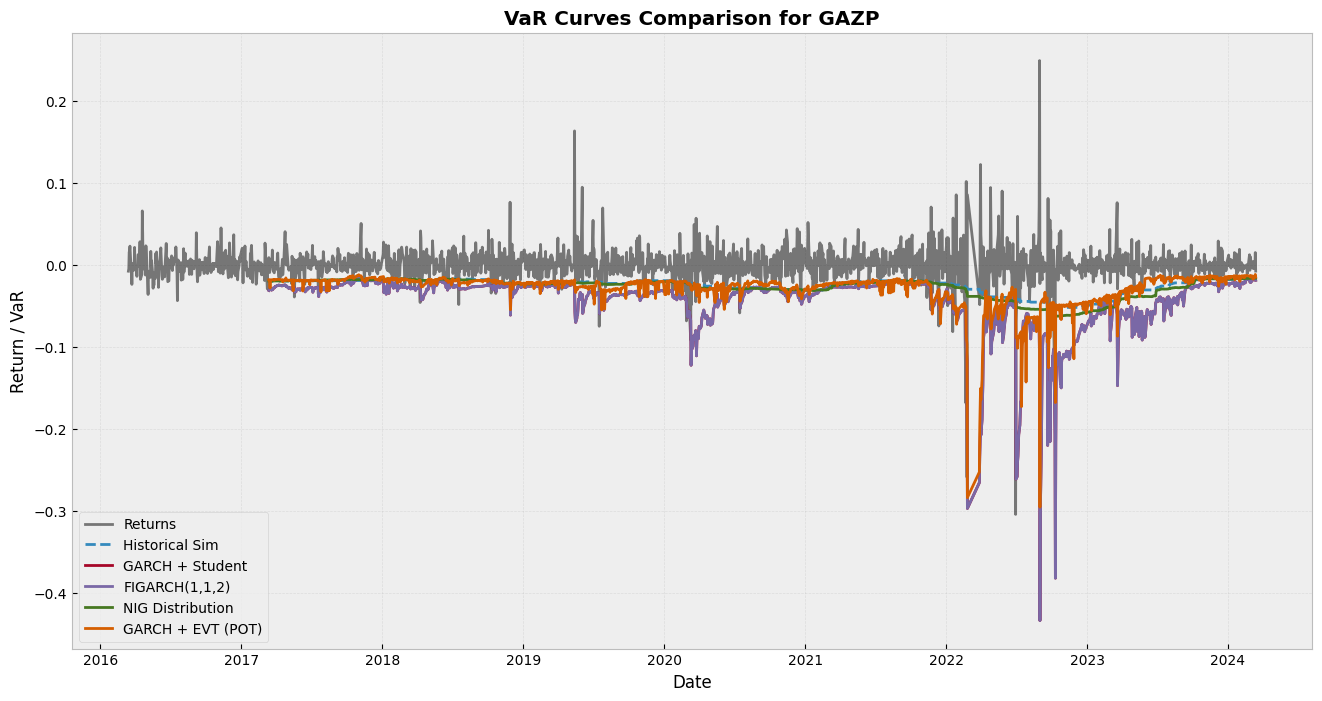

In [62]:
fig = plt.figure(figsize=(16, 8))

plt.plot(ret.index, ret.values, label='Returns', color='black', alpha=0.5)
plt.plot(VaR_HS.index, VaR_HS.values, label='Historical Sim', linestyle='--')
plt.plot(VaR_GARCH_Student.index, VaR_GARCH_Student.values, label='GARCH + Student')
plt.plot(VaR_FIGARCH.index, VaR_FIGARCH.values, label='FIGARCH(1,1,2)')
plt.plot(VaR_NIG.index, VaR_NIG.values, label='NIG Distribution')
plt.plot(VaR_GARCH_EVT.index, VaR_GARCH_EVT.values, label='GARCH + EVT (POT)', linewidth=2)

plt.title('VaR Curves Comparison for GAZP', weight='bold')
plt.xlabel('Date')
plt.ylabel('Return / VaR')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

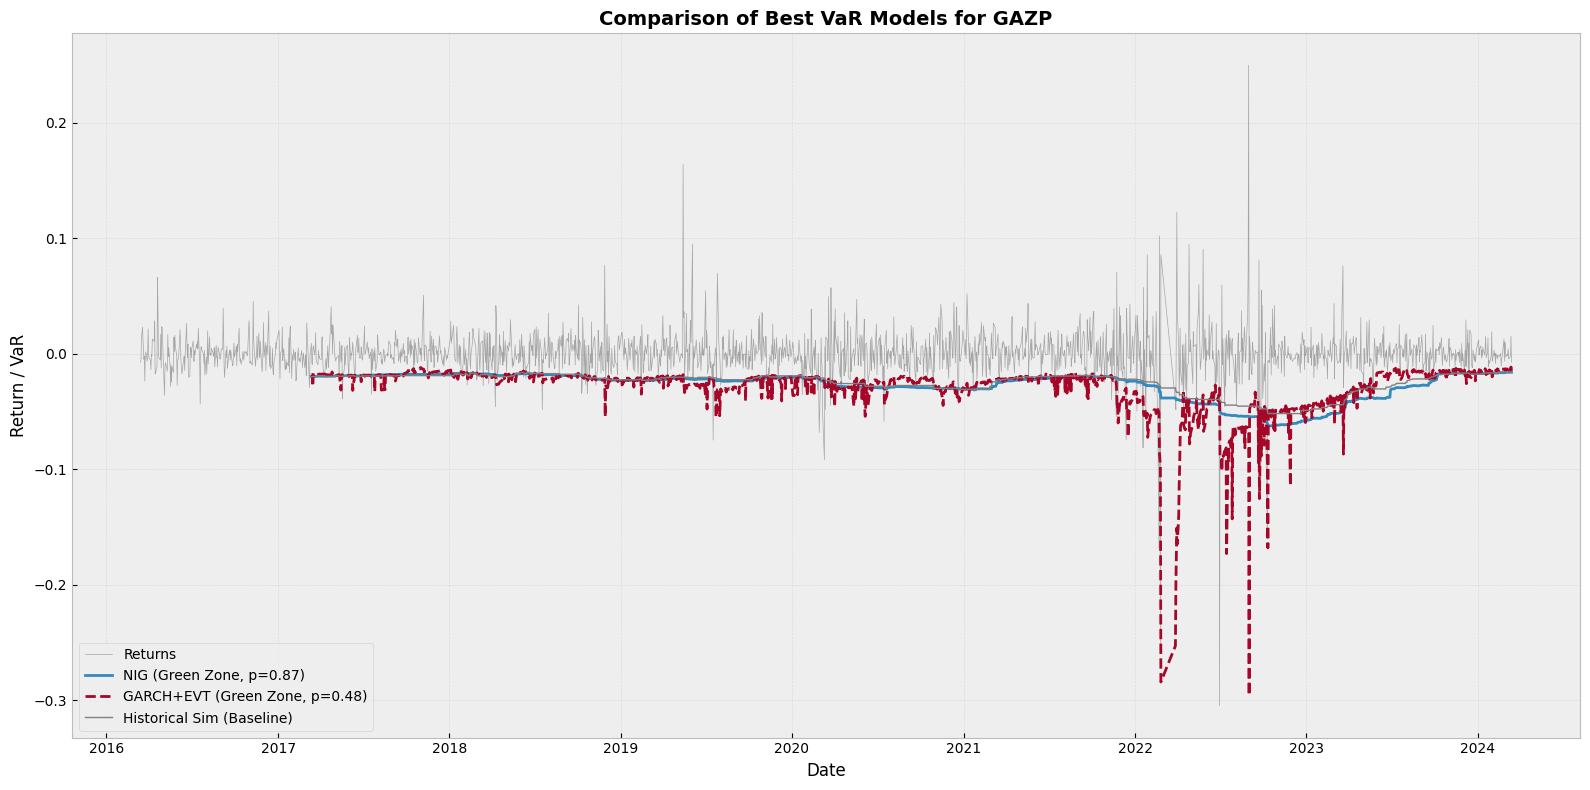

In [63]:
#лучшие модели
fig = plt.figure(figsize=(16, 8))

plt.plot(ret.index, ret.values, label='Returns', color='black', alpha=0.3, linewidth=0.5)
plt.plot(VaR_NIG.index, VaR_NIG.values, label='NIG (Green Zone, p=0.87)', linewidth=2)
plt.plot(VaR_GARCH_EVT.index, VaR_GARCH_EVT.values, label='GARCH+EVT (Green Zone, p=0.48)', linewidth=2, linestyle='--')
plt.plot(VaR_HS.index, VaR_HS.values, label='Historical Sim (Baseline)', linewidth=1, color='gray')

plt.title('Comparison of Best VaR Models for GAZP', weight='bold', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Return / VaR', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Результаты

1. Относительно полученного графика можно сделать выводы о том, что 
    - все модели адекватно реагируют на всплески волатильности (особенно заметно в 2020 и 2022 годах). В периоды спокойствия кривые VaR сходятся, но во время падений рынка расходятся, показывая разную оценку риска
    - кривые GARCH+ Student и FIGARCH часто находятся ниже остальных, предсказывая более крупные убытки. Как показал бектестинг, они слишком консервативны (перестраховываются и завышают риск), из-за чего попали в красную зону
    - модели NIG и GARCH+EVT ведут себя более гибко, лучше всего описывая реальные данные и не завышая риск без причины. Их кривые ближе всего к историческим экстремумам доходностей.

2. P-value для каждой модели

Backtesting calc_VaR_GARCH_Student:
The proportion of hits is 1.95% instead of expected 5.0%
Two-sided p-val 6.36e-11, one-sided: 1.0
red zone

Backtesting calc_VaR_FIGARCH:
The proportion of hits is 1.95% instead of expected 5.0%
Two-sided p-val 6.36e-11, one-sided: 1.0
red zone

Backtesting calculate_VaR_NIG:
The proportion of hits is 4.87% instead of expected 5.0%
Two-sided p-val 0.869, one-sided: 0.617
green zone

Backtesting calculate_VaR_GARCH_EVT:
The proportion of hits is 4.58% instead of expected 5.0%
Two-sided p-val 0.475, one-sided: 0.804
green zone


3. В данном случае лучше всего подошли параматерические методы с тяжелыми хвостами иди комбинация GARCH с теорией экстремальных значений (EVT), дающих статистически обоснованный прогноз (в отличие от простого исторического моделирования).